In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier



In [10]:
import pandas as pd

model = pd.read_csv("sample_submission.csv")
model2 = pd.read_csv("test.csv")
model3 = pd.read_csv("train.csv")

print(model.head())
print(model2.head())
print(model3.head())

       id  loan_paid_back
0  593994               0
1  593995               0
2  593996               0
3  593997               0
4  593998               0
       id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0  593994       28781.05                 0.049           626     11461.42   
1  593995       46626.39                 0.093           732     15492.25   
2  593996       54954.89                 0.367           611      3796.41   
3  593997       25644.63                 0.110           671      6574.30   
4  593998       25169.64                 0.081           688     17696.89   

   interest_rate  gender marital_status education_level employment_status  \
0          14.73  Female         Single     High School          Employed   
1          12.85  Female        Married        Master's          Employed   
2          13.29    Male         Single      Bachelor's          Employed   
3           9.57  Female         Single      Bachelor's          Employed

Target variable = loan payback

In [11]:
X = model3.drop(columns=['id', 'loan_paid_back'])
y = model3['loan_paid_back']


In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
X.dtypes


,0
annual_income,float64
debt_to_income_ratio,float64
credit_score,int64
loan_amount,float64
interest_rate,float64
gender,object
marital_status,object
education_level,object
employment_status,object
loan_purpose,object


In [14]:
#categorical_cols = X.select_dtypes(include=["object"]).columns
#numeric_cols = X.select_dtypes(exclude=["object"]).columns

#print("Categorical:", categorical_cols)
#print("Numeric:", numeric_cols)


Categorical: Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')
Numeric: Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate'],
      dtype='object')


Remapping to Numbers

In [23]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
model2 = pd.get_dummies(model2, drop_first=True)


In [24]:
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
model2 = model2.reindex(columns=X_train.columns, fill_value=0)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(model2)

Neural net

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

nn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=500,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

val_preds = nn.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))

Validation Accuracy: 0.9015227400904048


In [27]:
final_preds = nn.predict(test_scaled)

Logistics accuracy

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

preds = lr.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, preds))


Logistic Regression Accuracy: 0.8883913164252224


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decison Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

preds = dt.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, preds))


Decision Tree Accuracy: 0.8486687598380458


Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


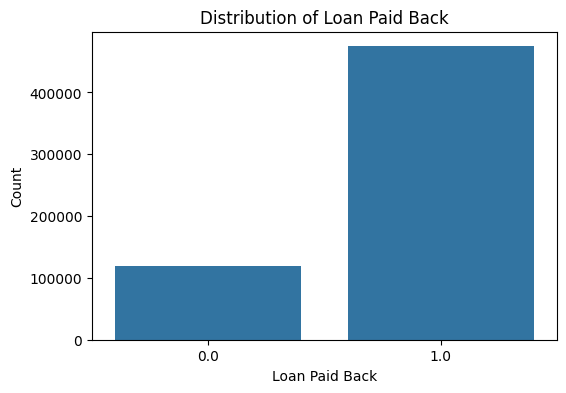

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=model3['loan_paid_back'])
plt.title("Distribution of Loan Paid Back")
plt.xlabel("Loan Paid Back")
plt.ylabel("Count")
plt.show()
